# Задача выделения сообществ и метрики оценки качества. Алгоритм Гирвана-Ньюмена. Лувенский алгоритм.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 3: Выделение сообществ"
* Документация:
    * https://networkx.org/documentation/stable/reference/readwrite/generated/networkx.readwrite.edgelist.read_edgelist.html
    * https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.remove_edges_from.html
    * https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.density.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.partition_quality.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.centrality.girvan_newman.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html
    * https://matplotlib.org/stable/users/explain/colors/colormaps.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.graphmatrix.adjacency_matrix.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.modularity_max.greedy_modularity_communities.html
* Дополнительные источники: 
   * https://arxiv.org/pdf/0906.0612.pdf

## Вопросы для совместного обсуждения

1\. Обсудите основные метрики для оценки качества выделенных сообществ и способы их вычисления.

2\. Обсудите принцип работы алгоритма Гирвана-Ньюмена и Лувенского алгоритма и реализации этих алгоритмов в `networkx.`


## Задачи для самостоятельного решения

In [1]:
import urllib.request
import tarfile
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity, partition_quality
from networkx.algorithms.community import louvain_communities

<p class="task" id="1"></p>

1\. Загрузите сеть `Southern women` с сайта http://konect.cc/, удалите из него петли и создайте не менее 5 разбиений этой сети на 2 сообщества (часть разбиений должны частично или полностью соответствовать интуитивным представлениям о разбиении на сообщества, часть - нет). Для создания разбиений не используйте специализированные алгоритмы. Визуализируйте графы, раскрасив узлы в цвет соответствующего им сообщества.

- [ ] Проверено на семинаре

C:\Users\Rog G16\AppData\Local\Temp\ipykernel_51500\67039921.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall()


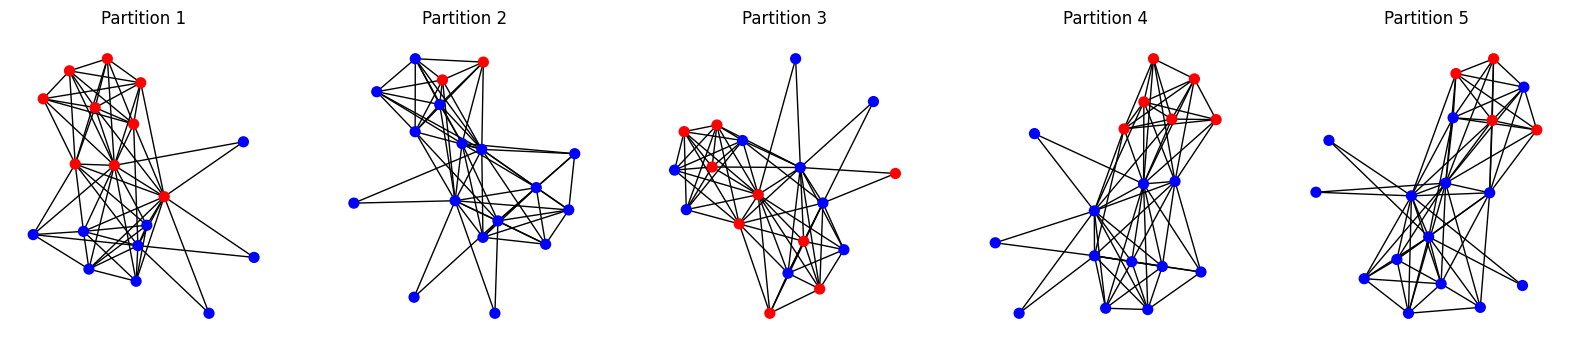

In [2]:
u = "http://konect.cc/files/download.tsv.opsahl-southernwomen.tar.bz2"
urllib.request.urlretrieve(u, "sw.tar.bz2")
with tarfile.open("sw.tar.bz2", "r:bz2") as t:
    t.extractall()

g = nx.read_edgelist("opsahl-southernwomen/out.opsahl-southernwomen", comments="%")
g.remove_edges_from(list(nx.selfloop_edges(g)))

n = list(g.nodes())
l = len(n)
p1 =[set(n[:l//2]), set(n[l//2:])]
p2 = [set(n[:2]), set(n[2:])]
p3 = [set(n[::2]), set(n[1::2])]
p4 = [set(n[:l//3]), set(n[l//3:])]
p5 = [set(n[:l//4]), set(n[l//4:])]
P = [p1, p2, p3, p4, p5]

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for i, p in enumerate(P):
    c = []
    for nd in g.nodes():
        if nd in p[0]:
            c.append('red')
        else:
            c.append('blue')
    nx.draw(g, ax=ax[i], node_color=c, node_size=50)
    ax[i].set_title(f"Partition {i+1}")
plt.show()

<p class="task" id="2"></p>

2\. Для разбиений из предыдущей задачи посчитайте следующие величины: 
* плотность первого сообщества
* плотность второго сообщества 
* среднюю плотность сообществ. 
* модулярность
* покрытие (coverage)
* эффективность (performance)

Все значения округлите до сотых и сведите в таблицу следующего вида:


| Разбиение                      | Плотность первого сообщества | Плотность второго сообщества | ... | ... |
|-------------------------------|-----------------------------|--------------|----------|----------|
| 1             |                             |              |          |          |
| ...                    |                             |              |          |          |

Для представления данных в табличном виде используйте `pandas`.

- [ ] Проверено на семинаре

In [3]:
r =[]
for i, p in enumerate(P):
    s1 = g.subgraph(p[0])
    s2 = g.subgraph(p[1])
    d1 = nx.density(s1)
    d2 = nx.density(s2)
    ad = (d1 + d2) / 2
    m = modularity(g, p)
    pq = partition_quality(g, p)
    cv = pq[0]
    pf = pq[1]
    r.append([
        f"P {i+1}", 
        round(d1, 2), 
        round(d2, 2), 
        round(ad, 2), 
        round(m, 2), 
        round(cv, 2), 
        round(pf, 2)
    ])

df = pd.DataFrame(
    r, 
    columns=[
        "Разбиение", 
        "Плотность первого сообщества", 
        "Плотность второго сообщества", 
        "Средняя плотность", 
        "Модулярность", 
        "Покрытие", 
        "Эффективность"
    ]
)
df

,Разбиение,Плотность первого сообщества,Плотность второго сообщества,Средняя плотность,Модулярность,Покрытие,Эффективность
0,P 1,0.83,0.42,0.62,0.18,0.70,0.70
1,P 2,1.00,0.43,0.72,0.01,0.83,0.48
2,P 3,0.44,0.36,0.40,-0.05,0.45,0.49
3,P 4,0.93,0.55,0.74,0.22,0.78,0.71
4,P 5,0.83,0.46,0.65,0.07,0.73,0.56


<p class="task" id="3"></p>

3\. Считайте сеть из файла `communities.edgelist`. Выполните разбиение сети на 2 сообщества с помощью алгоритма Гирвана-Ньюмена. Визуализируйте результат, раскрасив узлы в цвет, соответствующий их сообществу.

- [ ] Проверено на семинаре

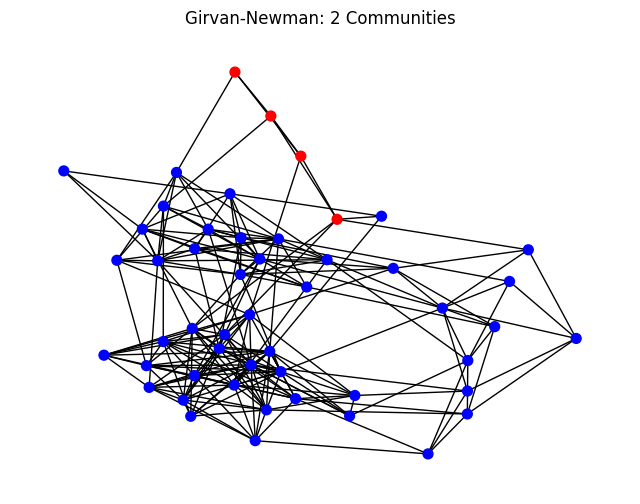

In [5]:
g2 = nx.read_edgelist("data/communities.edgelist")
gn = girvan_newman(g2)
c2 = next(gn)

c = []
for nd in g2.nodes():
    if nd in c2[0]:
        c.append('red')
    else:
        c.append('blue')

plt.figure(figsize=(8, 6))
plt.title("Girvan-Newman: 2 Communities")
nx.draw(g2, node_color=c, node_size=50)
plt.show()

<p class="task" id="4"></p>

4\. Постройте график динамики модулярности для шагов алгоритма Гирвана-Ньюмена. Визуализируйте разбиение сети из предыдущей задачи, при котором достигается наилучшее значение модулярности (выведите это значение на экран). Для визуализации выберите несколько цветов (в соответствии с количеством выделенных сообществ) и раскрасьте узлы __и связи__ в рамках одного сообщества этими цветами. Связи между узлами, состоящими в разных сообществах, отрисуйте черным цветом. 

- [ ] Проверено на семинаре

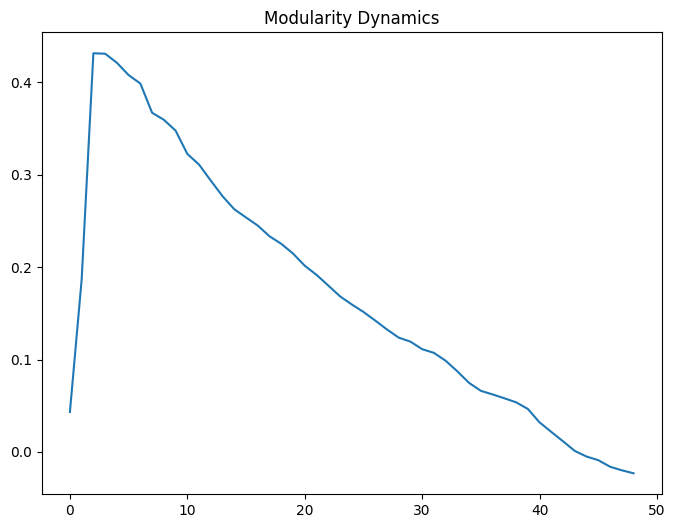

0.4315950788751715


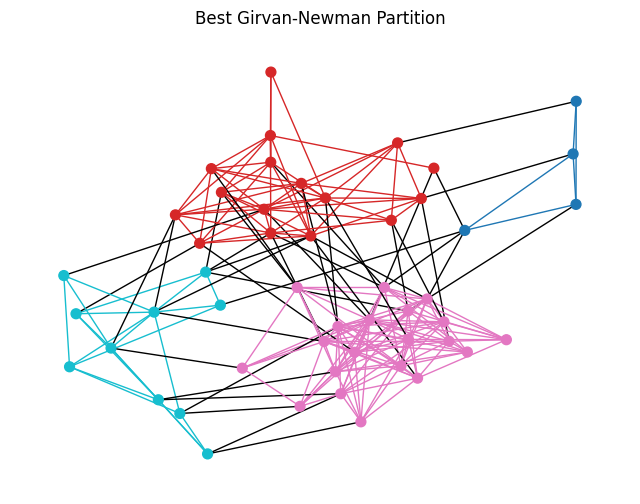

In [6]:
gn = girvan_newman(g2)
ml = []
pl =[]
for p in gn:
    ml.append(modularity(g2, p))
    pl.append(p)

plt.figure(figsize=(8, 6))
plt.plot(ml)
plt.title("Modularity Dynamics")
plt.show()

bi = np.argmax(ml)
bp = pl[bi]
print(ml[bi])

cm = plt.get_cmap('tab10', len(bp))
nc =[]
for nd in g2.nodes():
    for i, cs in enumerate(bp):
        if nd in cs:
            nc.append(cm(i))
            break

ec =[]
for u, v in g2.edges():
    s = False
    for i, cs in enumerate(bp):
        if u in cs and v in cs:
            ec.append(cm(i))
            s = True
            break
    if not s:
        ec.append('black')

plt.figure(figsize=(8, 6))
plt.title("Best Girvan-Newman Partition")
nx.draw(g2, node_color=nc, edge_color=ec, node_size=50)
plt.show()

<p class="task" id="5"></p>

5\. Выполните разбиение сети из первого задания на сообщества с помощью Лувенского алгоритма. Визуализируйте результат аналогично предыдущему заданию.

- [ ] Проверено на семинаре

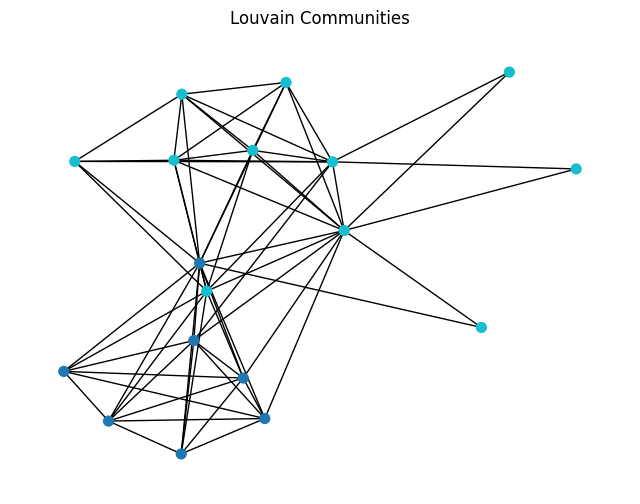

In [7]:
lv = louvain_communities(g)

cm = plt.get_cmap('tab10', len(lv))
c =[]
for nd in g.nodes():
    for i, cs in enumerate(lv):
        if nd in cs:
            c.append(cm(i))
            break

plt.figure(figsize=(8, 6))
plt.title("Louvain Communities")
nx.draw(g, node_color=c, node_size=50)
plt.show()

<p class="task" id="6"></p>

6\. Постройте матрицу смежности для сети. Постройте матрицу смежности для сети, в которой узлы перенумерованы в порядке возрастания номера сообщества, которому они принадлежат (т.е. номера $0...C_1-1$ даются $C_1$ узлам, принадлежащим первому сообществу; номера $C_1...C_2-1$ даются $C_2$ узлам, принадлежащим второму сообществу и т.д.). Для разбиения графа на сообщества воспользуйтесь Лувенским алгоритмом.

Визуализируйте две матрицы смежности при помощи `seaborn.heatmap`. Расположите рисунки рядом по горизонтали, добавьте названия рисунков. Сравните полученные изображения и сделайте выводы.

- [ ] Проверено на семинаре

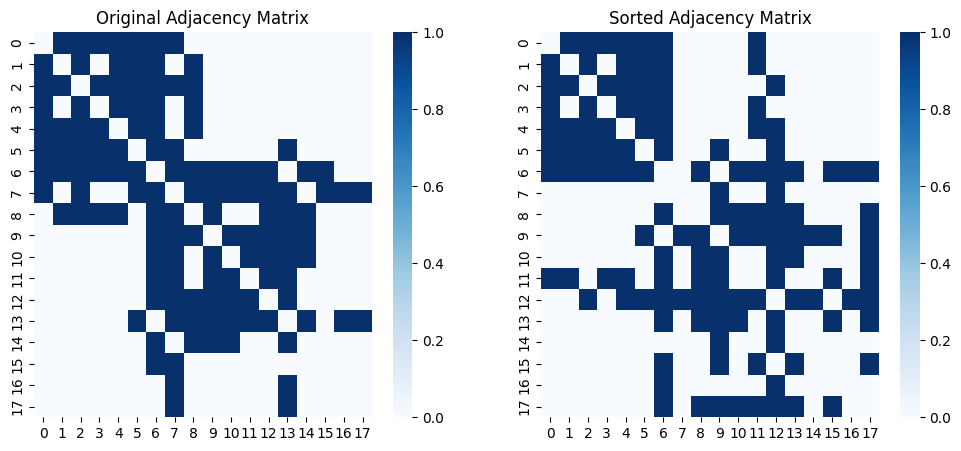

In [8]:
a1 = nx.adjacency_matrix(g).todense()

sn =[]
for cs in lv:
    sn.extend(list(cs))

a2 = nx.adjacency_matrix(g, nodelist=sn).todense()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(a1, ax=ax[0], cmap="Blues")
ax[0].set_title("Original Adjacency Matrix")

sns.heatmap(a2, ax=ax[1], cmap="Blues")
ax[1].set_title("Sorted Adjacency Matrix")

plt.show()